# Questão 1

Utilize a Equação (3.10) ou o Algoritmo 3.2 para construir polinômios interpoladores de graus um, dois e três para os dados a seguir. Faça a aproximação do valor especificado usando cada um dos polinômios:

**a)** f(8,4) se f(8,1) = 16,94410, f(8,3) = 17,56492, f(8,6) = 18,50515, f(8,7) = 18,82091

**b)** f(0,9) se f(0,6) = -0,17694460, f(0,7) = 0,01375227, f(0,8) = 0,22363362, f(1,0) = 0,65809197

Questão 1(a):
Grau 1: 17.875329999999998
Grau 2: 17.877129999999998
Grau 3: 17.877142499999998

Questão 1(b):
Grau 1: 0.39514601000000027
Grau 2: 0.4526994499999995
Grau 3: 0.4419850024999998


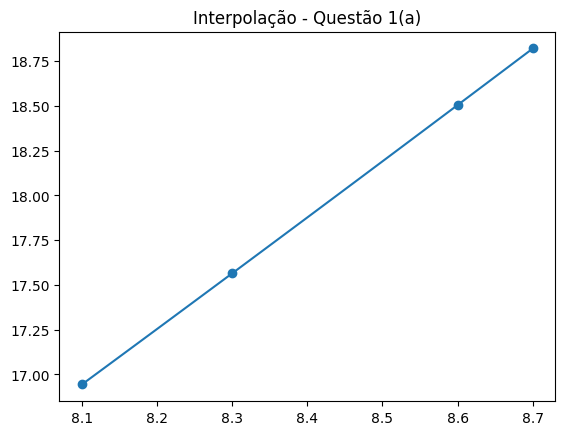

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

def diferencas_divididas(x, y):
    n = len(x)
    tabela = np.zeros((n, n))
    tabela[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            tabela[i][j] = (tabela[i+1][j-1] - tabela[i][j-1]) / (x[i+j] - x[i])

    return tabela


def newton(x, tabela, valor):
    n = len(x)
    resultado = tabela[0][0]
    produto = 1.0

    for i in range(1, n):
        produto *= (valor - x[i-1])
        resultado += tabela[0][i] * produto

    return resultado

# ITEM (a)

x1 = np.array([8.1, 8.3, 8.6, 8.7])
y1 = np.array([16.94410, 17.56492, 18.50515, 18.82091])

tabela1 = diferencas_divididas(x1, y1)

x_aprox = 8.4

print("Questão 1(a):")
print("Grau 1:", newton(x1[:2], tabela1[:2,:2], x_aprox))
print("Grau 2:", newton(x1[:3], tabela1[:3,:3], x_aprox))
print("Grau 3:", newton(x1, tabela1, x_aprox))

# ITEM (b)

x2 = np.array([0.6, 0.7, 0.8, 1.0])
y2 = np.array([-0.17694460, 0.01375227, 0.22363362, 0.65809197])

tabela2 = diferencas_divididas(x2, y2)

x_aprox = 0.9

print("\nQuestão 1(b):")
print("Grau 1:", newton(x2[:2], tabela2[:2,:2], x_aprox))
print("Grau 2:", newton(x2[:3], tabela2[:3,:3], x_aprox))
print("Grau 3:", newton(x2, tabela2, x_aprox))

# GRÁFICO (TESTE)

xx = np.linspace(8.1, 8.7, 50)  # diminuí pontos (mais leve)
yy = [newton(x1, tabela1, xi) for xi in xx]

plt.plot(xx, yy)
plt.scatter(x1, y1)
plt.title("Interpolação - Questão 1(a)")
plt.show()